Import các thư viện cần thiết như Numpy và Pandas

In [1]:
import numpy as np
import pandas as pd
print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.3.5
2.3.3


Đọc datasets

In [2]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [3]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [4]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

BIỂU ĐỒ BIẾN MỤC TIÊU

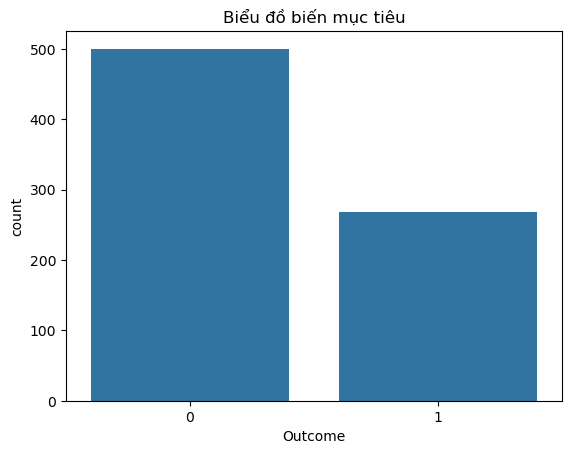

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.title('Biểu đồ biến mục tiêu')
plt.show()

In [17]:
# Số lượng class
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [18]:
df['Outcome'].value_counts(normalize = True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

=> Biểu đồ cho thấy số lượng người không mắc tiểu đường( Outcome = 0) nhiều hơn người bị mắc tiểu đường (Outcome = 1). 
Dữ liệu bị mất cân bằng giữa hai lớp.

CORRELATION HEATMAP

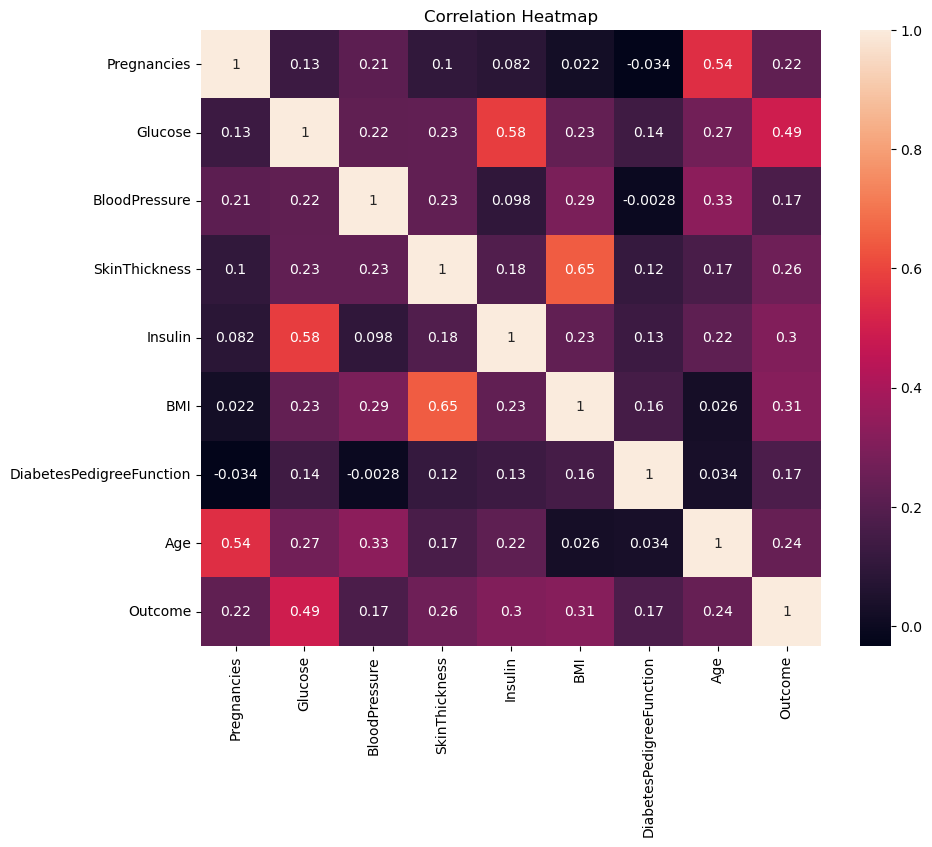

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
cmap="coolwwarm"
plt.title('Correlation Heatmap')
plt.show()
# Glucose có tương quan cao nhất với Outcome, cho thấy lượng đường trong máu ảnh hưởng lớn đến khả năng măc bệnh tiểu đường

=> Biểu đồ correlation heatmap cho thấy mối tương quan giữa các biến trong dataset.
+ "Glucose" có hệ số tương quan cao nhất với "Outcome" là 0.49 -> lượng đường cao dẫn đến khả năng mắc bệnh tiểu đường.